In [8]:
!pip install yfinance
import yfinance as yf
import pandas as pd

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------- -------------- 1.0/1.7 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 6.0 MB/s eta 0:00:00
  Attempting uninstall: cffi
    Found existing installation: cffi 1.17.1
    Uninstalling cffi-1.17.1:
      Successfully uninstalled cffi-1.17.1


In [10]:
btc = yf.download("BTC-USD", start="2019-01-01", end="2024-05-01")
btc.to_csv('BTC_Daily_Raw.csv')
print("Bitcoin data ready!")

[*********************100%***********************]  1 of 1 completed

Bitcoin data ready!


In [26]:
events = [
    {'date': '2020-03-11', 'event': 'WHO Declares COVID-19 Pandemic'},
    {'date': '2021-04-14', 'event': 'Coinbase IPO (Crypto Peak)'},
    {'date': '2022-02-24', 'event': 'Russia-Ukraine Conflict Begins'},
    {'date': '2022-11-08', 'event': 'FTX Exchange Collapse'},

    # 2023 Events
    {'date': '2023-03-10', 'event': 'US Banking Crisis (SVB Collapse)'},
    {'date': '2023-06-05', 'event': 'SEC Sues Binance'},
    {'date': '2023-06-06', 'event': 'SEC Sues Coinbase'},
    {'date': '2023-11-21', 'event': 'CZ Resigns from Binance'},
    {'date': '2023-04-12', 'event': 'Ethereum Shapella Upgrade'},

    # 2024 Events
    {'date': '2024-01-10', 'event': 'Bitcoin Spot ETF Approved'},
    {'date': '2024-04-20', 'event': 'Bitcoin Halving 2024'},
    {'date': '2024-05-23', 'event': 'Ethereum Spot ETF Approved'}
]

In [28]:
df_events = pd.DataFrame(events)
df_events['date'] = pd.to_datetime(df_events['date'])

In [30]:
df_events

,date,event
0,2020-03-11,WHO Declares COVID-19 Pandemic
1,2021-04-14,Coinbase IPO (Crypto Peak)
2,2022-02-24,Russia-Ukraine Conflict Begins
3,2022-11-08,FTX Exchange Collapse
4,2023-03-10,US Banking Crisis (SVB Collapse)
5,2023-06-05,SEC Sues Binance
6,2023-06-06,SEC Sues Coinbase
7,2023-11-21,CZ Resigns from Binance
8,2023-04-12,Ethereum Shapella Upgrade
9,2024-01-10,Bitcoin Spot ETF Approved


In [32]:
import matplotlib.pyplot as plt

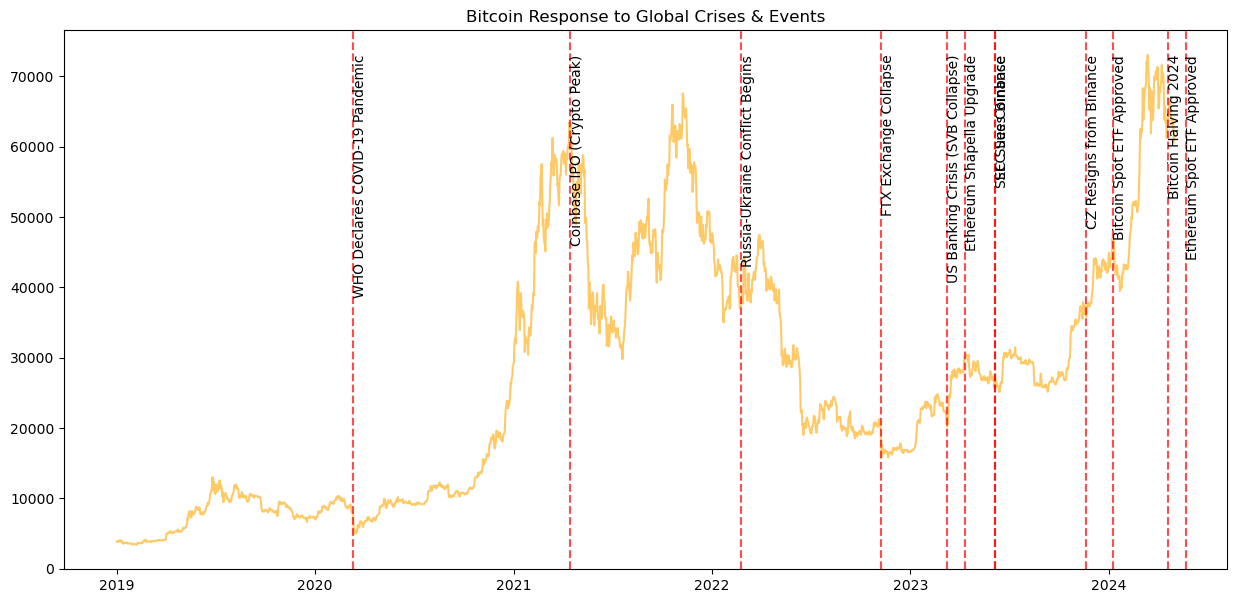

In [34]:
plt.figure(figsize=(15,7))
plt.plot(btc.index, btc['Close'],label="BTC price" , color = "Orange" , alpha=0.6)

for i,row in df_events.iterrows():
    plt.axvline(x=row['date'],color='red',linestyle='--',alpha=0.7)
    plt.text(row['date'], float(btc['Close'].max().iloc[0]), row['event'], rotation=90, verticalalignment='top')

plt.title('Bitcoin Response to Global Crises & Events')
plt.show()

In [56]:
def calc_impact(price_data, event_list, window=14):

    impact_results = []

    for event in event_list:

        event_date = pd.to_datetime(event['date'])

        if event_date in price_data.index:

            start_price = float(price_data.loc[event_date, 'Close'].iloc[0])

            after_event = price_data.loc[event_date : event_date + pd.Timedelta(days=window)]

            min_price = float(after_event['Low'].min().iloc[0])

            drop_pct = ((min_price - start_price) / start_price) * 100

            impact_results.append({
                'Event': event['event'],
                'Date': event['date'],
                'Price at Event ($)': round(start_price, 2),
                'Lowest Price After ($)': round(min_price, 2),
                'Max Drawdown (%)': round(drop_pct, 2)
            })

    return pd.DataFrame(impact_results)

impact_df = calc_impact(btc, events)
print("--- Global Event Impact Table ---")
print(impact_df)

--- Global Event Impact Table ---
                               Event        Date  Price at Event ($)  \
0     WHO Declares COVID-19 Pandemic  2020-03-11             7911.43   
1         Coinbase IPO (Crypto Peak)  2021-04-14            63109.70   
2     Russia-Ukraine Conflict Begins  2022-02-24            38332.61   
3              FTX Exchange Collapse  2022-11-08            18541.27   
4   US Banking Crisis (SVB Collapse)  2023-03-10            20187.24   
5                   SEC Sues Binance  2023-06-05            25760.10   
6                  SEC Sues Coinbase  2023-06-06            27238.78   
7            CZ Resigns from Binance  2023-11-21            35813.81   
8          Ethereum Shapella Upgrade  2023-04-12            30139.05   
9          Bitcoin Spot ETF Approved  2024-01-10            46627.78   
10              Bitcoin Halving 2024  2024-04-20            64994.44   

    Lowest Price After ($)  Max Drawdown (%)  
0                  4106.98            -48.09  
1      

In [58]:
impact_df.to_csv('BTC_Global_Event_Impact_Summary.csv', index=False)

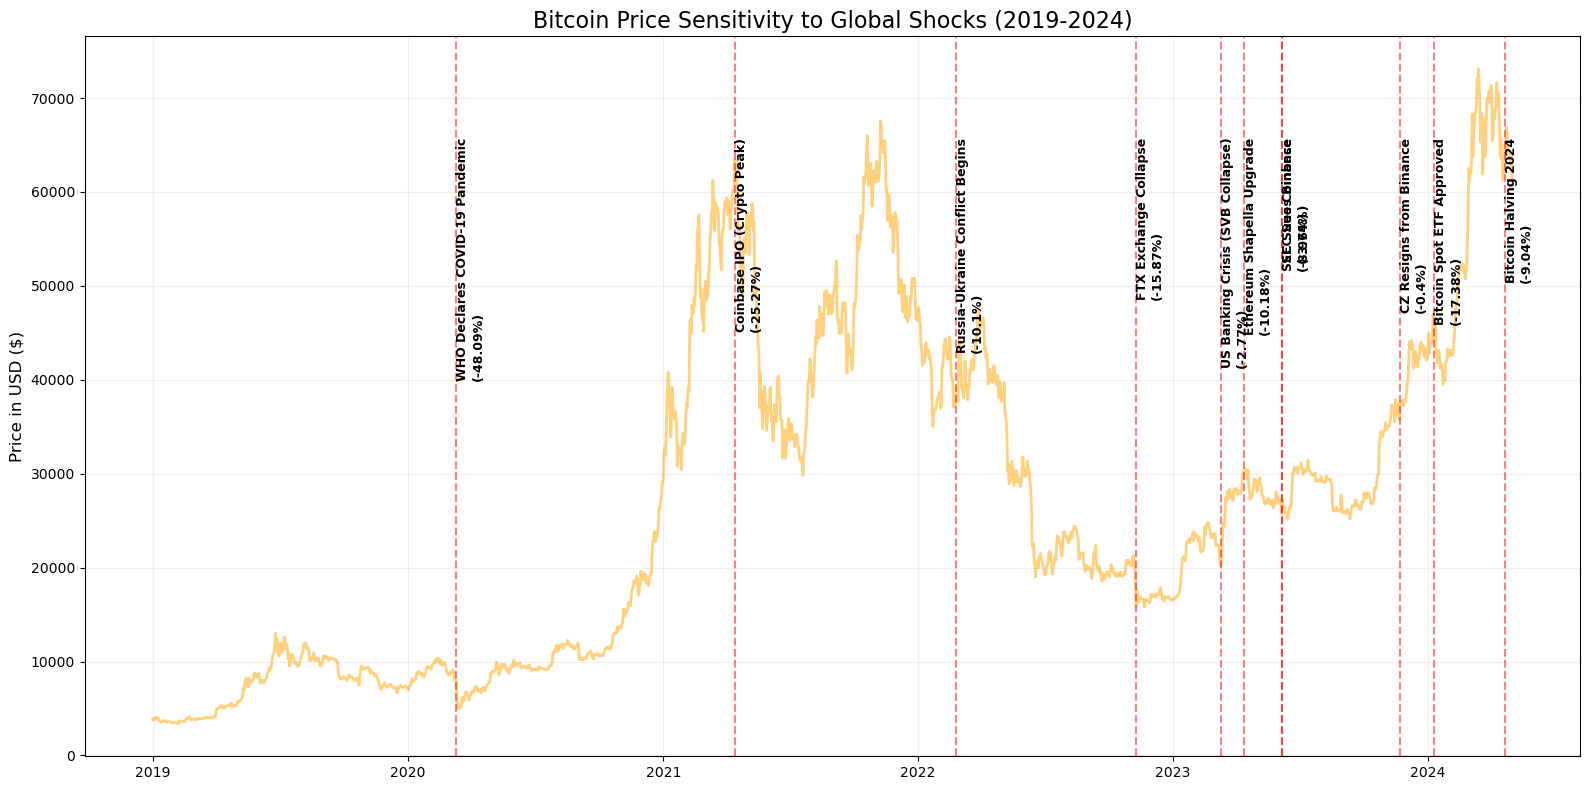

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
plt.plot(btc.index, btc['Close'], label='BTC Price', color='orange', alpha=0.5, linewidth=2)

for i, row in impact_df.iterrows():
    event_date = pd.to_datetime(row['Date'])
    plt.axvline(x=event_date, color='red', linestyle='--', alpha=0.5)
    
    plt.text(event_date, btc['Close'].max() * 0.9, 
             f"{row['Event']}\n({row['Max Drawdown (%)']}%)", 
             rotation=90, verticalalignment='top', fontsize=9, fontweight='bold')

plt.title('Bitcoin Price Sensitivity to Global Shocks (2019-2024)', fontsize=16)
plt.ylabel('Price in USD ($)', fontsize=12)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('btc_event_analysis.png')
plt.show()